# 01 — The Basics (Hello World)

This notebook shows the minimal workflow:
1) build a `TorchExpr` once from a SymPy `Integral`
2) evaluate the integral numerically using Torch-only code


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import torch
import sympy as sp

# Allow `import torchsympy` from a src-layout checkout
ROOT = Path.cwd().parents[1]
SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import torchsympy

device = torch.device('cpu')
dtype = torch.float64
print('torchsympy version:', getattr(torchsympy, '__version__', 'unknown'))

torchsympy version: 0.3.0


In [2]:
# Define a classic Gaussian integral: ∫ exp(-x^2) dx = sqrt(pi)
x = sp.Symbol('x', real=True)
integral = sp.Integral(sp.exp(-x**2), (x, -sp.oo, sp.oo))

lt = torchsympy.TorchSymPy()
texpr = lt.torchify(integral)

re, im = texpr.torchquad_integrate(N=121, dtype=dtype)
re_t = torch.as_tensor(re, device=device, dtype=dtype)
im_t = torch.as_tensor(im, device=device, dtype=dtype)
expected = torch.sqrt(torch.tensor(torch.pi, device=device, dtype=dtype))

print('Result   :', re_t.item(), '+', im_t.item(), 'i')
print('Expected :', expected.item())
print('Abs error:', (re_t - expected).abs().item())

Result   : 1.7724520431833266 + 0.0 i
Expected : 1.772453850905516
Abs error: 1.807722189495209e-06


c:\Users\Pc\Desktop\LOCALS\F_Nutku_Studies\.venv\Lib\site-packages\torchquad\integration\utils.py:262: UserWarning: DEPRECATION WARNING: In future versions of torchquad, an array-like object will be returned.
  warnings.warn(


In [5]:
# Same integral via the built-in batched quadrature (Simpson rule on tensor-product grid)
re2, im2 = texpr.torch_integrate_batched(
    params_values=None,
    method='simpson',
    N=401,
    device=device,
    dtype=dtype,
)

print('Batched result:', float(re2), '+', float(im2), 'i')
print('Abs error     :', float((re2 - expected).abs()))

Batched result: 1.772453850905516 + 0.0 i
Abs error     : 0.0


Saved: c:\Users\Pc\Desktop\LOCALS\F_Nutku_Studies\LibTorch\examples\plots\01_gaussian_integrand.png


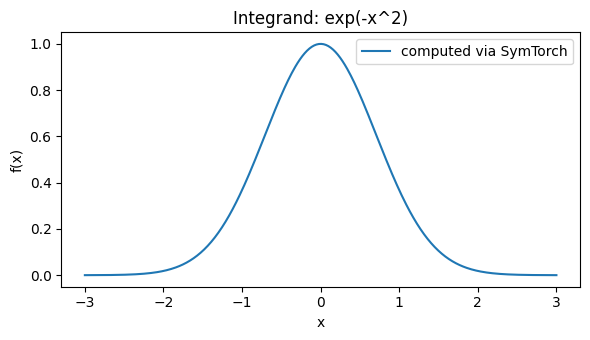

In [6]:
# A small plot (saved under examples/plots/)
import matplotlib.pyplot as plt

xs = torch.linspace(-3.0, 3.0, 400, device=device, dtype=dtype)
ys = torch.exp(-xs**2)

plt.figure(figsize=(6, 3.5))
plt.plot(xs.cpu().numpy(), ys.cpu().numpy(), label='computed via SymTorch')
plt.title('Integrand: exp(-x^2)')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.tight_layout()

out_path = ROOT / 'examples' / 'plots' / '01_gaussian_integrand.png'
plt.savefig(out_path, dpi=150)
print('Saved:', out_path)
